In [2]:
#installing packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

In [11]:
# reading data
raw_data = pd.read_csv("C:/Users/Niko/Downloads/YYZ_data.csv")

In [12]:
print(raw_data.head())
print(raw_data.columns)
print(raw_data.info())
print(raw_data.isna().sum())
print(raw_data.duplicated().sum())

  Op. Al. Name (Dominant) Arr Airport Code Arr City Name Arr Country Name  \
0              Air Canada              YVR     Vancouver           Canada   
1              Air Canada              YUL      Montreal           Canada   
2              Air Canada              YYC       Calgary           Canada   
3                 Westjet              YYC       Calgary           Canada   
4                 Westjet              YVR     Vancouver           Canada   

   Gateway1 Airport Code  Total Est. Pax  Time Series  
0                    NaN          919149         2022  
1                    NaN          572855         2022  
2                    NaN          532999         2022  
3                    NaN          532684         2022  
4                    NaN          398695         2022  
Index(['Op. Al. Name (Dominant)', 'Arr Airport Code', 'Arr City Name',
       'Arr Country Name', 'Gateway1 Airport Code', 'Total Est. Pax',
       'Time Series'],
      dtype='object')
<class 'pandas.

In [24]:
df = raw_data.copy()

df.columns = df.columns.str.strip()

#Renaming columns if needed
df = df.rename(columns={
    "Time Series": "year",
    "Op. Al. Name (Dominant)": "airline",
    "Arr Airport Code": "dest_airport",
    "Arr City Name": "dest_city",
    "Arr Country Name": "dest_country",
    "Gateway1 Airport Code": "gateway1",
    "Total Est. Pax": "passengers"
})

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["passengers"] = pd.to_numeric(df["passengers"], errors="coerce")

df = df.dropna(subset=["year", "passengers"])
df["year"] = df["year"].astype(int)

In [25]:
# Check for duplicates
df = df.drop_duplicates()

In [27]:
# Create market categories

# Forecast is about transborder = US
# non US international = all non Canada and non US markets

def classify_market(country):
    if country == "United States":
        return "Transborder_US"
    elif country == "Canada":
        return "Domestic"
    else:
        return "NonUS_International"

df["market"] = df["dest_country"].apply(classify_market)

In [32]:
# Keeping two markets I am interested in
yyz_markets = df[df["market"].isin(["Transborder_US", "NonUS_International"])].copy()

In [33]:
# Aggregate annual passenger demand
annual_market = (
    yyz_markets.groupby(["year", "market"], as_index=False)["passengers"].sum()
)

In [34]:
# Creating a pivot table for plotting and forecasting:
annual_pivot = annual_market.pivot(index="year", columns="market", values="passengers")
print(annual_pivot)

market  NonUS_International
year                       
2012               10680681
2013               10466330
2014               10817628
2015               11845650
2016               13069657
2017               14608465
2018               15594813
2019               15244616
2020                3983266
2021                2735846
2022               11166798
2023               14584729
2024               15621834
2025               15555213


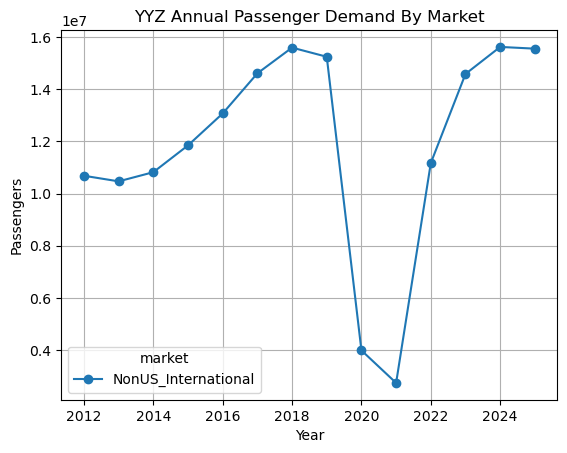

In [39]:
#Trend by market
annual_pivot.plot(marker="o")

plt.title("YYZ Annual Passenger Demand By Market")
plt.ylabel("Passengers")
plt.xlabel("Year")
plt.grid(True)
plt.show()

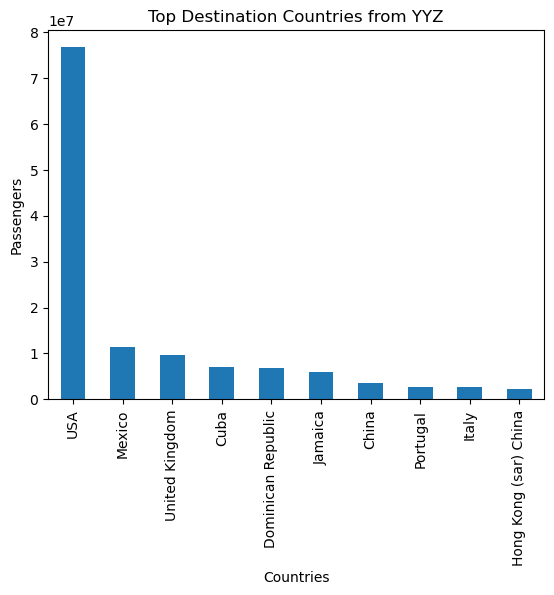

In [38]:
#Top destination countries
top_countries = (
    yyz_markets.groupby("dest_country")["passengers"].sum().sort_values(ascending=False).head(10)
)

top_countries.plot(kind="bar")
plt.title("Top Destination Countries from YYZ")
plt.ylabel("Passengers")
plt.xlabel("Countries")
plt.show()

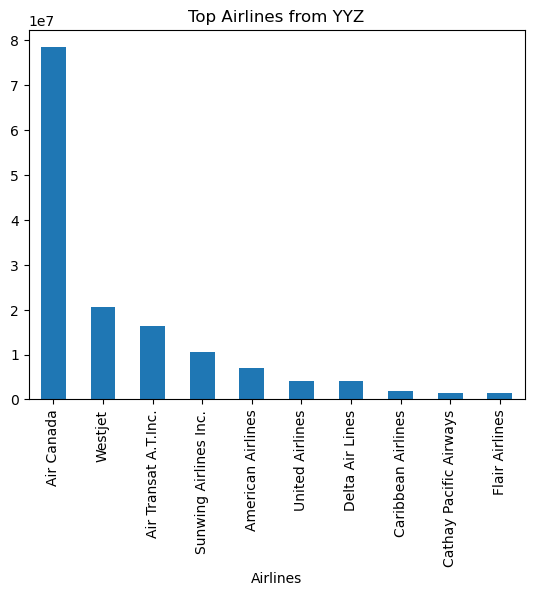

In [43]:
# Airlines by market
top_airlines = (
    yyz_markets.groupby("airline")["passengers"].sum().sort_values(ascending=False).head(10)
)
top_airlines.plot(kind="bar")
plt.title("Top Airlines from YYZ")
plt.xlabel("Passengers")
plt.xlabel("Airlines")
plt.show()